In [ ]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Upload the manufacturing dataset

uploaded = files.upload()

Saving manufacturing_dataset_1000_samples.csv to manufacturing_dataset_1000_samples.csv


In [ ]:
# Step 2: Load and inspect the dataset

df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

First 5 rows:
             Timestamp  Injection_Temperature  Injection_Pressure  Cycle_Time  \
0  2023-01-01 00:00:00                  221.0               136.0        28.7   
1  2023-01-01 01:00:00                  213.3               128.9        34.5   
2  2023-01-01 02:00:00                  222.8               115.9        19.9   
3  2023-01-01 03:00:00                  233.3               105.3        39.2   
4  2023-01-01 04:00:00                  212.2               125.5        45.0   

   Cooling_Time  Material_Viscosity  Ambient_Temperature  Machine_Age  \
0          13.6               375.5                 28.0          3.8   
1          14.0               215.8                 22.6          6.8   
2           9.5               307.0                 25.3          4.2   
3          13.1               137.8                 26.0          9.2   
4           9.9               298.2                 23.6          6.2   

   Operator_Experience  Maintenance_Hours    Shift Machine_T

In [ ]:
# Step 3: Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp                      0
Injection_Temperature          0
Injection_Pressure             0
Cycle_Time                     0
Cooling_Time                   0
Material_Viscosity            20
Ambient_Temperature           20
Machine_Age                    0
Operator_Experience           20
Maintenance_Hours              0
Shift                          0
Machine_Type                   0
Material_Grade                 0
Day_of_Week                    0
Temperature_Pressure_Ratio     0
Total_Cycle_Time               0
Efficiency_Score               0
Machine_Utilization            0
Parts_Per_Hour                 0
dtype: int64


In [ ]:
# Step 4: Statistical Summary

print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
count            1000.000000         1000.000000  1000.00000    1000.00000   
mean              215.315900          116.075000    35.85170      11.92320   
std                11.995507           14.667246     8.35349       2.30429   
min               180.000000           80.000000    16.30000       8.00000   
25%               207.200000          105.900000    28.80000      10.27500   
50%               215.300000          115.950000    36.85000      11.90000   
75%               222.800000          125.925000    45.00000      13.50000   
max               300.000000          150.000000    60.00000      19.90000   

       Material_Viscosity  Ambient_Temperature  Machine_Age  \
count          980.000000           980.000000  1000.000000   
mean           251.630714            22.941224     7.855900   
std             73.348695             2.773712     3.900798   
min            104.6000

In [ ]:
# Step 5: Process Timestamp

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month

# Remove original timestamp
df = df.drop("Timestamp", axis=1)

print("\nAfter Timestamp Processing:")
print(df.head())


After Timestamp Processing:
   Injection_Temperature  Injection_Pressure  Cycle_Time  Cooling_Time  \
0                  221.0               136.0        28.7          13.6   
1                  213.3               128.9        34.5          14.0   
2                  222.8               115.9        19.9           9.5   
3                  233.3               105.3        39.2          13.1   
4                  212.2               125.5        45.0           9.9   

   Material_Viscosity  Ambient_Temperature  Machine_Age  Operator_Experience  \
0               375.5                 28.0          3.8                 11.2   
1               215.8                 22.6          6.8                  6.3   
2               307.0                 25.3          4.2                  9.6   
3               137.8                 26.0          9.2                  8.6   
4               298.2                 23.6          6.2                 23.0   

   Maintenance_Hours    Shift  ... Material_G

In [ ]:
# Step 6: Identify column types and handle missing values

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

print("\nCategorical Columns:")
print(categorical_columns.tolist())

# Numerical columns → fill missing values with median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Categorical columns → fill missing values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMissing Values After Processing:")
print(df.isnull().sum())

Numerical Columns:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']

Categorical Columns:
['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']

Missing Values After Processing:
Injection_Temperature         0
Injection_Pressure            0
Cycle_Time                    0
Cooling_Time                  0
Material_Viscosity            0
Ambient_Temperature           0
Machine_Age                   0
Operator_Experience           0
Maintenance_Hours             0
Shift                         0
Machine_Type                  0
Material_Grade                0
Day_of_Week                   0
Temperature_Pressure_Ratio    0
Total_Cycle_Time              0
Efficiency_Score              0
Machine_Utilization           0
Parts_Per_Hour               

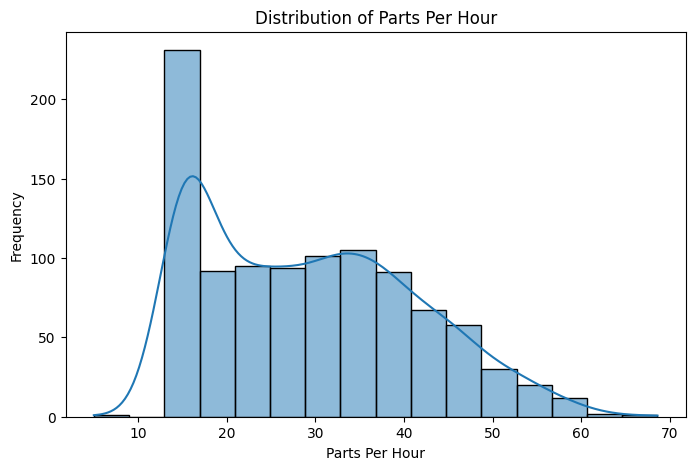

In [ ]:
# Step 7: Target Distribution it shows how parts per hour value are distributed among the records


plt.figure(figsize=(8, 5))

sns.histplot(
    df["Parts_Per_Hour"],
    kde=True
)

plt.title("Distribution of Parts Per Hour")
plt.xlabel("Parts Per Hour")
plt.ylabel("Frequency")

plt.show()

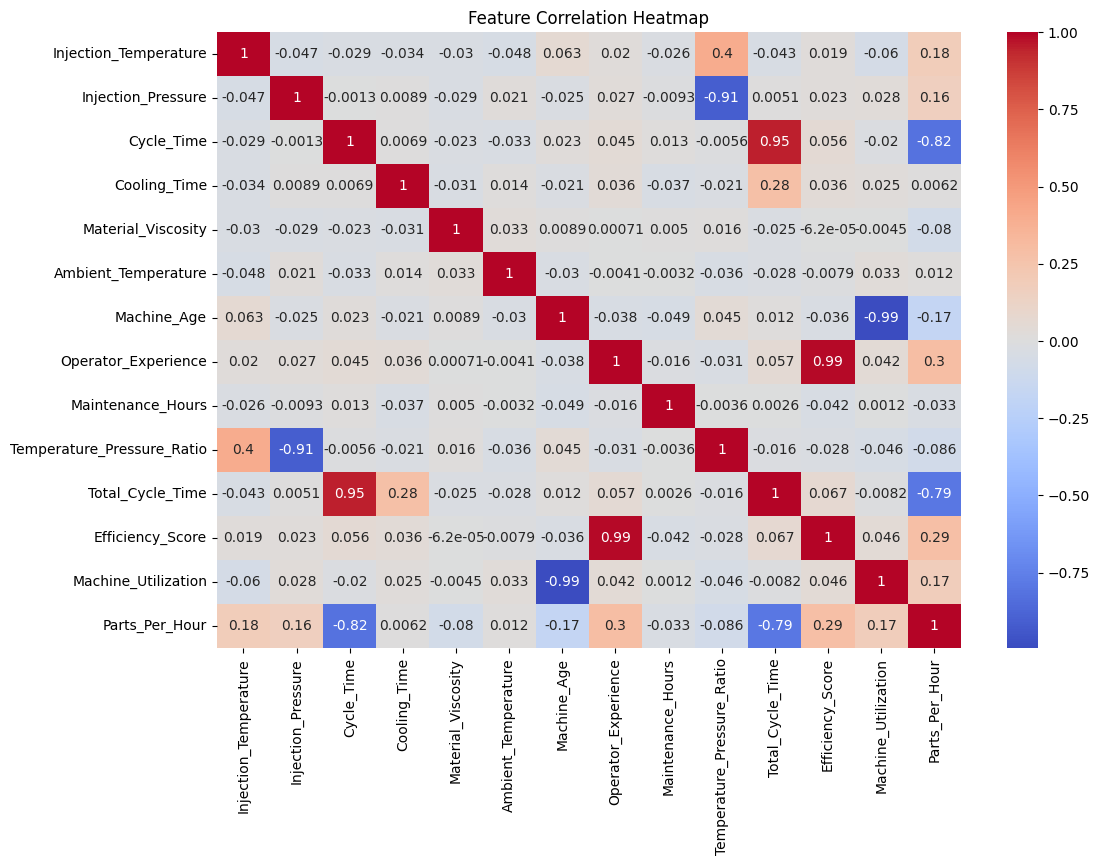

In [ ]:
# Step 8: Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation = df.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

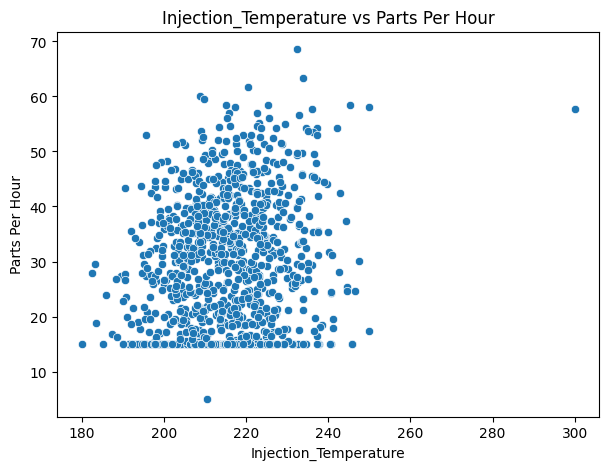

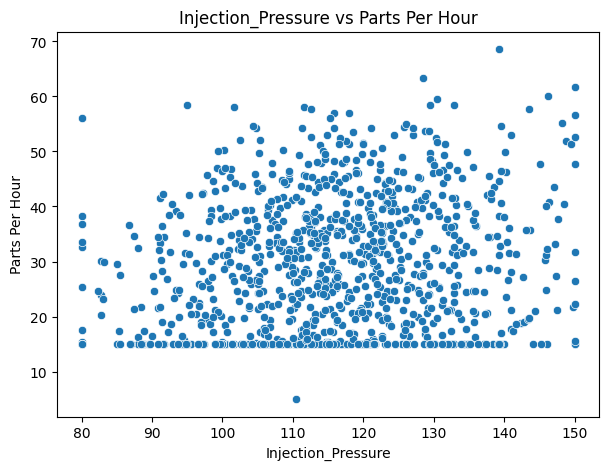

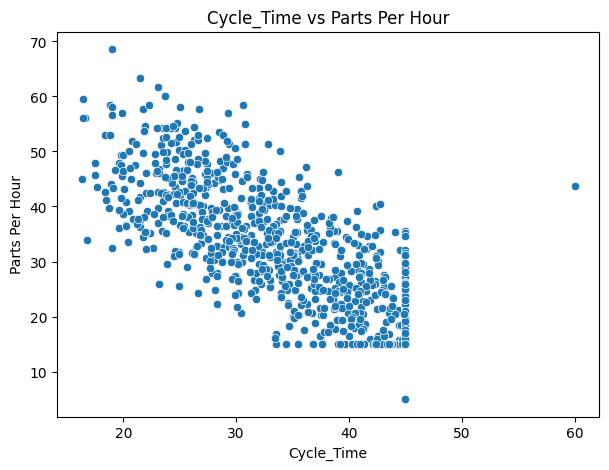

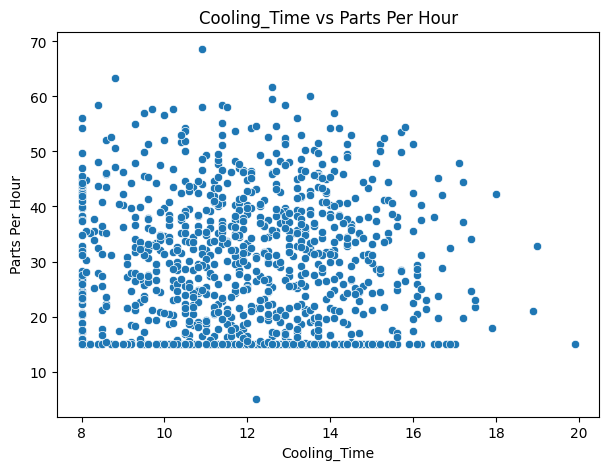

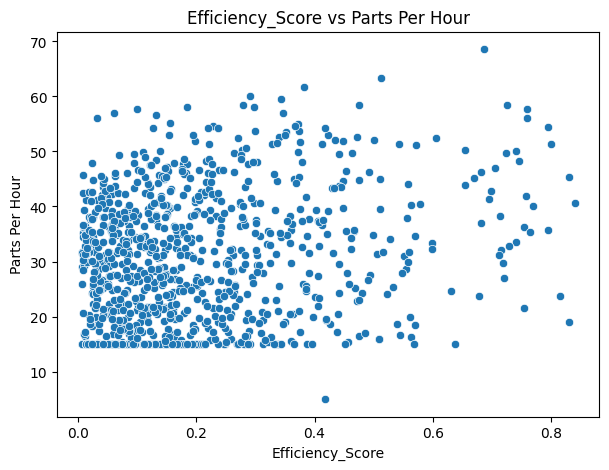

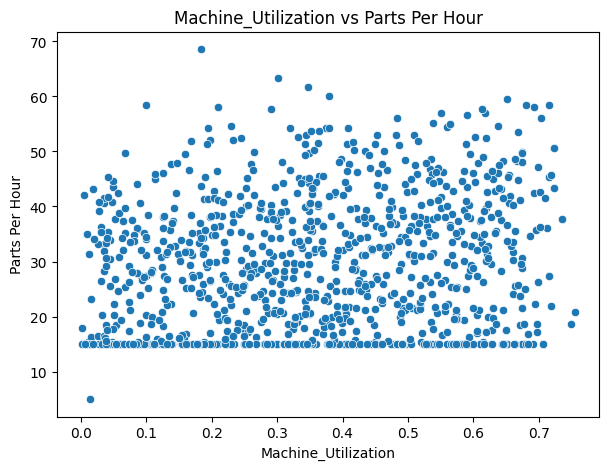

In [ ]:
# Step 9: Important Feature Relationships

features = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Efficiency_Score",
    "Machine_Utilization"
]

for feature in features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        x=df[feature],
        y=df["Parts_Per_Hour"]
    )

    plt.title(
        feature + " vs Parts Per Hour"
    )

    plt.xlabel(feature)
    plt.ylabel("Parts Per Hour")

    plt.show()

In [ ]:
# Step 10: Save Processed Dataset

df.to_csv(
    "processed_manufacturing_dataset.csv",
    index=False
)

print("\nProcessed dataset saved successfully!")


Processed dataset saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from skle free arn.linear_model import LinearRegression

# -----------------------------------
# 1. Load Dataset
# -----------------------------------

df = pd.read_csv(
    "manufacturing_dataset_1000_samples.csv"
)

# -----------------------------------
# 2. Process Timestamp
# -----------------------------------

df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    errors="coerce"
)

df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day
df["Month"] = df["Timestamp"].dt.month

df = df.drop(
    "Timestamp",
    axis=1
)

# -----------------------------------
# 3. Define Target
# -----------------------------------

X = df.drop(
    "Parts_Per_Hour",
    axis=1
)

y = df["Parts_Per_Hour"]

# -----------------------------------
# 4. Identify Columns
# -----------------------------------

categorical_columns = [
    "Shift",
    "Machine_Type",
    "Material_Grade",
    "Day_of_Week"
]

numerical_columns = [
    column
    for column in X.columns
    if column not in categorical_columns
]

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# -----------------------------------
# 5. Numerical Pipeline
# -----------------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# -----------------------------------
# 6. Categorical Pipeline
# -----------------------------------

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# -----------------------------------
# 7. Preprocessor
# -----------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

# -----------------------------------
# 8. Linear Regression Model
# -----------------------------------

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "regression",
            LinearRegression()
        )
    ]
)

# -----------------------------------
# 9. Train-Test Split
# -----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))

# -----------------------------------
# 10. Train Model
# -----------------------------------

model.fit(
    X_train,
    y_train
)

print("\nModel trained successfully!")

# -----------------------------------
# 11. Predictions
# -----------------------------------

predictions = model.predict(
    X_test
)
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\nModel Performance:")
print("MAE :", round(mae, 2))
print("MSE :", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))
print("R2 Percentage:", round(r2 * 100, 2), "%")

print("\nFirst 10 Predictions:")

for actual, predicted in zip(
    y_test[:10],
    predictions[:10]
):
    print(
        "Actual:",
        round(actual, 2),
        "Predicted:",
        round(predicted, 2)
    )

# -----------------------------------
# 12. Save Model
# -----------------------------------

joblib.dump(
    model,
    "manufacturing_linear_regression.joblib"
)

print(
    "\nModel saved as "
    "manufacturing_linear_regression.joblib"
)

Numerical Columns:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Hour', 'Day', 'Month']

Categorical Columns:
['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']

Training Records: 800
Testing Records: 200

Model trained successfully!

Model Performance:
MAE : 2.73
MSE : 12.32
RMSE: 3.51
R2 Score: 0.9056
R2 Percentage: 90.56 %

First 10 Predictions:
Actual: 18.6 Predicted: 20.04
Actual: 42.8 Predicted: 44.72
Actual: 34.2 Predicted: 34.33
Actual: 40.0 Predicted: 39.87
Actual: 15.0 Predicted: 18.36
Actual: 15.0 Predicted: 20.65
Actual: 33.6 Predicted: 33.7
Actual: 15.0 Predicted: 14.23
Actual: 25.0 Predicted: 27.95
Actual: 24.2 Predicted: 32.21

Model saved as manufacturing_linear_regression.joblib


In [ ]:
from fastapi import FastAPI
import pandas as pd
import joblib

# -----------------------------------
# Load Model
# -----------------------------------

model = joblib.load(
    "manufacturing_linear_regression.joblib"
)

# -----------------------------------
# Create FastAPI App
# -----------------------------------

app = FastAPI(
    title="Manufacturing Equipment Output Prediction",
    description="Linear Regression API for predicting Parts Per Hour",
    version="1.0"
)

# -----------------------------------
# Home
# -----------------------------------

@app.get("/")
def home():

    return {
        "message":
        "Manufacturing Output Prediction API",
        "status": "running"
    }

# -----------------------------------
# Prediction Endpoint
# -----------------------------------

@app.post("/predict")
def predict(data: dict):

    df = pd.DataFrame([data])

    # Process timestamp
    if "Timestamp" in df.columns:

        df["Timestamp"] = pd.to_datetime(
            df["Timestamp"],
            errors="coerce"
        )

        df["Hour"] = df["Timestamp"].dt.hour
        df["Day"] = df["Timestamp"].dt.day
        df["Month"] = df["Timestamp"].dt.month

        df = df.drop(
            "Timestamp",
            axis=1
        )

    # Prediction
    prediction = model.predict(df)

    return {
        "Predicted_Parts_Per_Hour":
        round(float(prediction[0]), 2)
    }

In [ ]:
new_machine = pd.DataFrame([
    {
        "Injection_Temperature": 220,
        "Injection_Pressure": 90,
        "Cycle_Time": 13,
        "Cooling_Time": 5,
        "Material_Viscosity": 120,
        "Ambient_Temperature": 25,
        "Machine_Age": 5,
        "Operator_Experience": 4,
        "Maintenance_Hours": 20,
        "Shift": "Day",
        "Machine_Type": "Type_A",
        "Material_Grade": "Standard",
        "Day_of_Week": "Monday",
        "Temperature_Pressure_Ratio": 2.59,
        "Total_Cycle_Time": 16,
        "Efficiency_Score": 0.80,
        "Machine_Utilization": 0.85,
        "Hour": 10,
        "Day": 2,
        "Month": 1
    }
])

In [ ]:
prediction = model.predict(new_machine)

print(
    "Predicted Parts Per Hour:",
    round(prediction[0], 2)
)

Predicted Parts Per Hour: 70.42
